In [1]:
import zipfile
from pathlib import Path
from astropy.io import fits
import re
import matplotlib.pyplot as plt
import numpy as np
import pyphot
from pyphot import UnitFilter
import pandas as pd
import numpy as np

In [ ]:
root_dir = Path('/Users/lucakrattinger/LOCAL_FILES/synthetic/AMBRE')
pattern = re.compile(r'[a-zA-Z_]*[ps](\d+)'r'g([0-9.]+)'r'z([-\d.]+)'r'.*?_a([-\d.]+)')

nb_spectra = 0
teff_list, logg_list, feh_list, alpha_list = [], [], [], []

# Run this only the first time to get all of the data from the zip files

# Loop over all outer ZIP files
for outer_zip in root_dir.glob('*.zip'):
    print(f"Processing outer ZIP: {outer_zip.name}")

    # Loop over all inner ZIP files
    with zipfile.ZipFile(outer_zip, 'r') as outer:
        for inner_name in outer.namelist():
            if not inner_name.endswith('.zip'):
                continue
            
            # Loop over all FITS files
            with outer.open(inner_name) as inner_zip_bytes:
                with zipfile.ZipFile(inner_zip_bytes) as inner:
                    for fits_name in inner.namelist():
                        if not fits_name.endswith('.FITS'):
                            continue
                        
                        # Extract stellar parameters from filename
                        match = pattern.search(fits_name)
                        if match:
                            teff_list.append(float(match.group(1)))
                            logg_list.append(float(match.group(2)))
                            feh_list.append(float(match.group(3)))
                            alpha_list.append(float(match.group(4)))
                            nb_spectra += 1
                        else:
                            print("Skipped FITS with unexpected name:", fits_name)

print("Spectra with extracted stellar parameters:", nb_spectra)

Processing outer ZIP: AMBRE_-5.0.zip
Processing outer ZIP: AMBRE_-1.5.zip
Processing outer ZIP: AMBRE_-3.0.zip
Processing outer ZIP: AMBRE_+0.0.zip
Processing outer ZIP: AMBRE_-1.0.zip
Processing outer ZIP: AMBRE_-2.5.zip
Processing outer ZIP: AMBRE_-4.0.zip
Processing outer ZIP: AMBRE_-0.5.zip
Processing outer ZIP: AMBRE_-2.0.zip
Spectra with extracted stellar parameters: 2647


In [2]:
# Load  data if the above loop has already been run once
df = pd.read_parquet('/Users/lucakrattinger/Documents/MA1-EPFL/TP4/code/calculated_magnitudes.parquet')

feh_list = df['feh'].tolist()
logg_list = df['logg'].tolist()
alpha_list = df['alpha'].tolist()
teff_list = df['teff'].tolist()

teff = np.array(teff_list)
logg = np.array(logg_list)
feh = np.array(feh_list)
alpha = np.array(alpha_list)
nb_spectra=2647


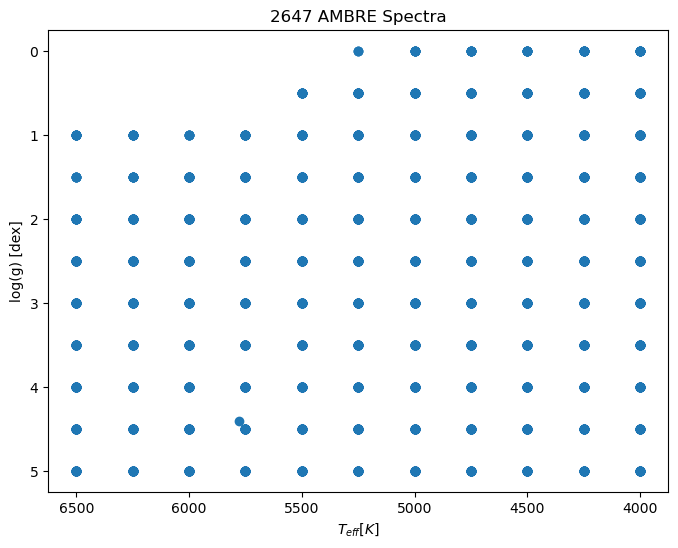

In [3]:
# Plot log g vs Teff
plt.figure(figsize=(8,6))
sc1 = plt.scatter(teff,logg)
plt.gca().invert_xaxis()  # Spectroscopic convention: hotter stars on the left
plt.gca().invert_yaxis() 
plt.xlabel(r'$T_{eff} [K]$')
plt.ylabel('log(g) [dex]')
plt.title(f'{nb_spectra} AMBRE Spectra')

plt.show()

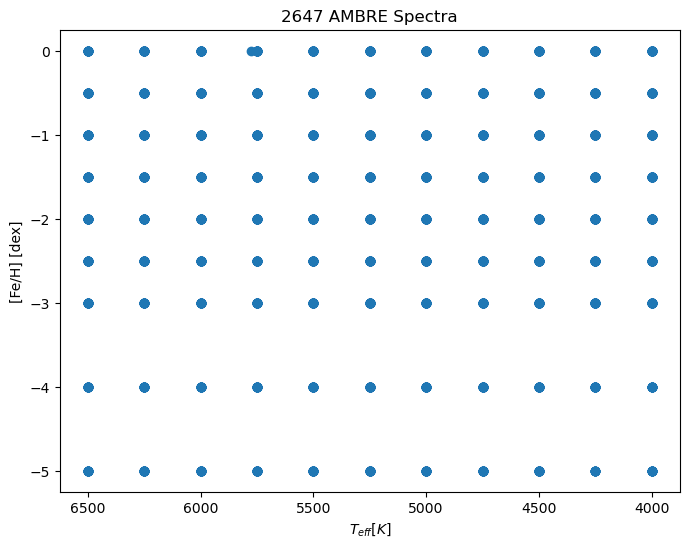

In [4]:
# Plot [Fe/H] vs Teff
plt.figure(figsize=(8,6))
sc2 = plt.scatter(teff,feh)
plt.gca().invert_xaxis()  # Spectroscopic convention: hotter stars on the left
plt.xlabel(r'$T_{eff} [K]$')
plt.ylabel('[Fe/H] [dex]')
plt.title(f'{nb_spectra} AMBRE Spectra')

plt.show()

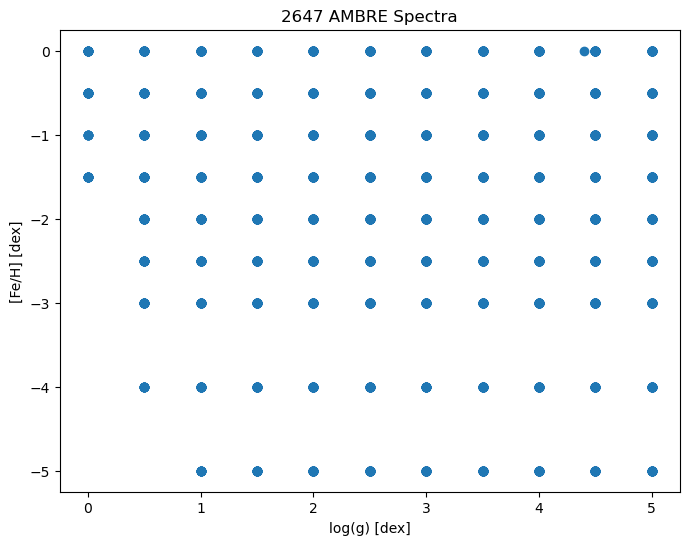

In [5]:
# Plot [Fe/H] vs log g
plt.figure(figsize=(8,6))
sc3 = plt.scatter(logg,feh)
plt.xlabel(r'log(g) [dex]')
plt.ylabel('[Fe/H] [dex]')
plt.title(f'{nb_spectra} AMBRE Spectra')

plt.show()

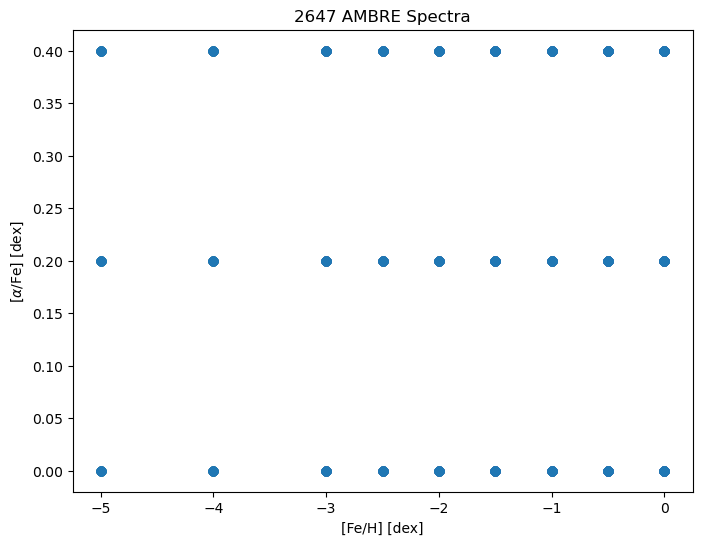

In [6]:
# Plot [alpha/Fe] vs [Fe/H]
plt.figure(figsize=(8,6))
sc4 = plt.scatter(feh,alpha)
plt.xlabel(r'[Fe/H] [dex]')
plt.ylabel(r'[$ \alpha$/Fe] [dex]')
plt.title(f'{nb_spectra} AMBRE Spectra')

plt.show()

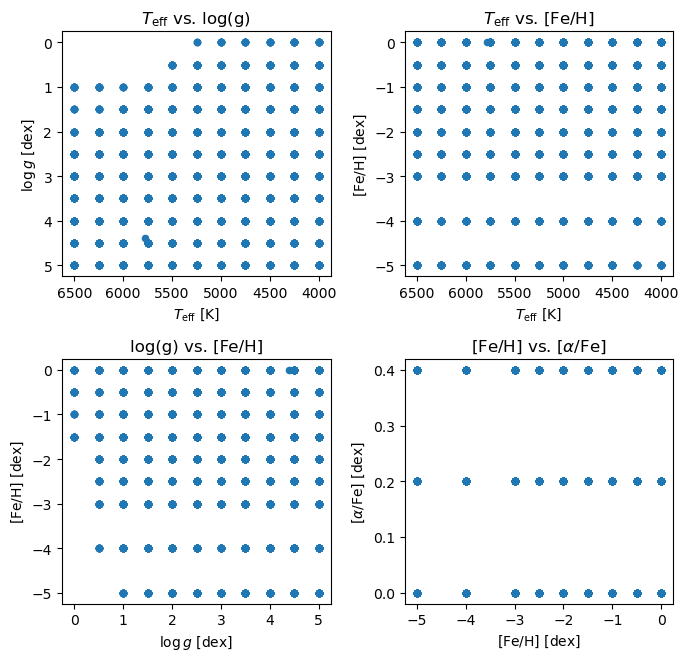

In [8]:
fig, axes = plt.subplots(2,2, figsize=(7, 7))
# Top-Left: Teff vs. log(g) 
ax0 = axes[0, 0]
ax0.scatter(teff, logg, s=20)
ax0.invert_xaxis() 
ax0.invert_yaxis()
ax0.set_xlabel(r'$T_{\text{eff}} \ [\text{K}]$')
ax0.set_ylabel(r'$\log g \ [\text{dex}]$')
ax0.set_title(r'$T_{\text{eff}}$ vs. log(g)')

# Top-Right: Teff vs. [Fe/H]
ax1 = axes[0, 1]
ax1.scatter(teff, feh, s=20)
ax1.invert_xaxis() # Teff inverted
ax1.set_xlabel(r'$T_{\text{eff}} \ [\text{K}]$')
ax1.set_ylabel(r'$[\text{Fe/H}] \ [\text{dex}]$')
ax1.set_title(r'$T_{\text{eff}}$ vs. [Fe/H]')

# Bottom-Left: log(g) vs. [Fe/H]
ax2 = axes[1, 0]
ax2.scatter(logg, feh, s=20)
ax2.set_xlabel(r'$\log g \ [\text{dex}]$')
ax2.set_ylabel(r'$[\text{Fe/H}] \ [\text{dex}]$')
ax2.set_title('log(g) vs. [Fe/H]')

# Bottom-Right: [Fe/H] vs. [alpha/Fe] 
ax3 = axes[1, 1]
ax3.scatter(feh, alpha, s=20)
ax3.set_xlabel(r'$[\text{Fe/H}] \ [\text{dex}]$')
ax3.set_ylabel(r'$[\alpha/\text{Fe}] \ [\text{dex}]$')
ax3.set_title(r'$[\text{Fe/H}] \ \text{vs.} \ [\alpha/\text{Fe}]$')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('stellar_parameters.svg', format='svg', bbox_inches='tight')
plt.show()